In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [22]:
df=pd.read_csv('data_gd.csv')

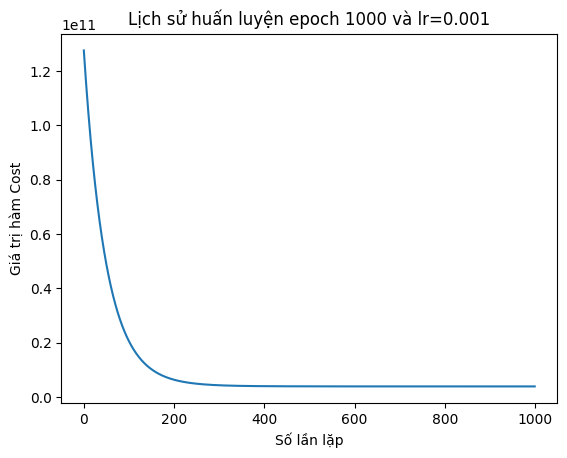

In [ ]:
def forward_pass(size,bedroom,b0,b1,b2):
    y_pred=b0+b1*size+b2*bedroom
    return y_pred

def loss(y_pred,y):
    return np.mean((y_pred-y)**2)

def gradient(X,y,n_iteration,lr):
    n_samples, n_features = X.shape
    weights = np.zeros((n_features, 1))
    bias=0.0
    y = y.reshape((-1, 1))
    cost_his=[]
    for _ in range(n_iteration):
        y_pred=np.dot(X,weights)+bias
        w=-(1/n_samples)*np.dot(X.T,(y-y_pred))
        b=-(1/n_samples)*np.sum(y-y_pred)
        weights=weights-lr*w
        bias=bias-lr*b
        cost=loss(y_pred,y)
        cost_his.append(cost)
    return weights,bias,cost_his
X=df[['size','bedroom']].values
y=df['price'].values

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=32) 
# chuẩn hóa dữ liệu
stand_scaler = StandardScaler()
X_train_scaled = stand_scaler.fit_transform(X_train)
X_test_scaled = stand_scaler.transform(X_test)
weights,bias,cost_his=gradient(X_train_scaled,y_train,1000,lr=0.001)


plt.plot([i for i in range(1000)],cost_his)
plt.title('Lịch sử huấn luyện epoch 1000 và lr=0.001')
plt.xlabel("Số lần lặp")
plt.ylabel('Giá trị hàm Cost')
plt.show()

In [ ]:
def gradient_descent(X, y, learning_rate, n_iterations):
    n_samples, n_features = X.shape
    weights = np.zeros((n_features, 1))
    bias=0.0
    y = y.reshape((-1, 1))
    cost_his=[]
    for _ in range(n_iterations):
        z = np.dot(X, weights)+bias
        p = sigmoid(z)
        w = np.dot(X.T, (p-y)) / n_samples
        b=  np.sum(p-y)/n_samples
        weights= weights-learning_rate * w
        bias= bias-learning_rate * b
        cost=cost_function(y,p)
        cost_his.append(cost)
    # print(cost_his[-1])

    return weights,bias,cost_his